<a href="https://colab.research.google.com/github/leoruggiero/Sprint-8-Python-Leonardo-Ruggiero/blob/main/Sprint8_Python_LeonardoRuggiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarea S8.01. Analítica de datos en Pandas


# Nivel 1 - EDA estructurado y limpieza básica

## Ejercicio 1: Exploración inicial del dataset
---

🎯 Objetivo: entender la estructura general del dataset y detectar posibles problemas antes de empezar a limpiar o transformar datos.
En este ejercicio debes realizar una exploración inicial del DataFrame para responder, como mínimo, a las siguientes preguntas:



**Primero hago la importacion de datos.**

In [1]:
# importacion de datos

from google.colab import files
uploaded = files.upload()

Saving sprint8_complex.xlsx to sprint8_complex.xlsx


**Cuántas filas y columnas tiene el dataset?**

---

RESPUESTA: Utilizando el atributo '.shape' sobre el DataFrame, obtuve una tupla que me indica exactamente 1010 filas y 20 columnas.

In [2]:
import pandas as pd
import io

nome_del_arquivo = 'sprint8_complex.xlsx'

df = pd.read_excel(io.BytesIO(uploaded[nome_del_arquivo]))

print(df.shape)

(1010, 20)


**Qué tipo de datos contiene cada columna?**

---

Al ejecutar el método `.info()`, he comprobado que las 20 columnas están catalogadas con el tipo de dato `object`. Esto ocurre porque Pandas está interpretando todo como texto, lo cual me alerta de un problema evidente, ya que tenemos variables que claramente deberían ser numéricas (como el salario o los años) o booleanas.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Dades de l'enquesta de treballadors 2025  1008 non-null   object
 1   Unnamed: 1                                1007 non-null   object
 2   Unnamed: 2                                1007 non-null   object
 3   Unnamed: 3                                1007 non-null   object
 4   Unnamed: 4                                1007 non-null   object
 5   Unnamed: 5                                1007 non-null   object
 6   Unnamed: 6                                1007 non-null   object
 7   Unnamed: 7                                1007 non-null   object
 8   Unnamed: 8                                1007 non-null   object
 9   Unnamed: 9                                967 non-null    object
 10  Unnamed: 10                               1007 n

**Hay filas duplicadas?**

---

Apliqué el método `.duplicated()` para identificar registros repetidos en todo el DataFrame y lo encadené con `.sum()` para obtener el recuento total. El resultado arrojado fue 0, por lo que concluyo que no hay filas completamente idénticas en esta primera carga.

In [4]:
total_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {total_duplicados}")
if total_duplicados > 0:
    print("\nMuestra de filas duplicadas:")
    display(df[df.duplicated()].head())

Filas duplicadas: 0


**Los datos parecen coherentes a primera vista?**

---

Al imprimir la muestra con `df.describe(include='all')`, observé directamente que las filas de índice 0 y 1 contienen metadatos sueltos ("Generades aleatòriament per seguretat") y valores `NaN`. Los nombres reales de las variables están en la fila 2. Esto explica exactamente por qué `.sample()` nos devolvió columnas nombradas genéricamente como `Unnamed: 1`.

In [5]:
df.describe()



,Dades de l'enquesta de treballadors 2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
count,1008,1007,1007,1007,1007,1007,1007,1007,1007,967,1007,420,586,1006,1006,710,659,316,262,937
unique,1008,104,469,992,7,46,36,16,52,10,856,2,3,6,15,9,3,171,85,187
top,990,AdriÃ,Ferrer,90585882A,Espanya,Palma,10.0,9.0,1982.0,D,n/d,True,True,Grup A,Data Analyst,0.0,False,80000,25.0,-5.0
freq,1,34,22,6,719,58,38,90,32,325,14,419,584,466,142,292,330,74,61,21


 » Detectas posibles problemas o inconsistencias evidentes?

 ---

Problemas graves con el nombre de las columnas, de formato en datos numéricos en salarios, falta de un padron en Género : (`'Dona', 'H', 'D', 'F', 'Home', 'NC', 'M', nan, 'A', '??'`), problemas de Encoding (Caracteres extraños `'CÃrrec'`
) y redundancia estructural en el diseño del dataset (`'Fills'`, `'No Fills'` y `'Nombre_fills'`)

In [6]:

print(df['Unnamed: 10'].unique()[:10])
print(df.isna().sum())
print(df['Unnamed: 9'].unique()[:10])
print(df['Unnamed: 11'].unique()[:10])

[nan 'Salari mensual' '1,469 â‚¬' '2,718 â‚¬' '1358 euros' '1,478 â‚¬'
 '1,284 â‚¬' '2,069 â‚¬' '2,349 â‚¬' '2,855 â‚¬']
Dades de l'enquesta de treballadors 2025      2
Unnamed: 1                                    3
Unnamed: 2                                    3
Unnamed: 3                                    3
Unnamed: 4                                    3
Unnamed: 5                                    3
Unnamed: 6                                    3
Unnamed: 7                                    3
Unnamed: 8                                    3
Unnamed: 9                                   43
Unnamed: 10                                   3
Unnamed: 11                                 590
Unnamed: 12                                 424
Unnamed: 13                                   4
Unnamed: 14                                   4
Unnamed: 15                                 300
Unnamed: 16                                 351
Unnamed: 17                                 694
Unnamed: 18    

## Ejercicio 2: Validaciones básicas de los datos y decisiones de eliminación

---

En este ejercicio tendrás que validar aspectos clave del dataset que son críticos en cualquier contexto real de análisis de datos, tomando decisiones justificadas sobre la validez o eliminación de registros .


» Corregir posibles problemas de codificación y acentuación en los nombres de las columnas y en los valores de texto, si procede.
» Detectar y eliminar filas duplicadas exactas, indicando cuántos registros se han eliminado.

» Comprobar la unicidad del DNI. En caso de detectar DNIs duplicados, deberás analizar la coherencia de la información asociada y descartar o anular los registros que no sean fiables, justificando claramente la decisión tomada.

» Identificar los campos clave que no deberían contener valores nulos, detectar registros con información insuficiente y eliminar únicamente aquellas filas completamente vacías o con información irrecuperable o no sustituible, explicando por qué no es posible ni razonable imputarlas.


**Cargo y limpieza**

---

Antes de empezar el ejercicio, tuve que cargas los datos hacendo la limpieza de la primera columna que es un indice oculto de pandas `if datos_trabajadores.columns[0].startswith('Unnamed')`. Luego reconstruyo el dataset eliminando esa primera columna `iloc[:, 1:]`. Hice un print para comprobar el numero de filas e .head para saber se todo fue cargado correctamente.

In [7]:
import io

datos_trabajadores = pd.read_excel(io.BytesIO(uploaded[nome_del_arquivo]), sheet_name=0, skiprows=3)

if datos_trabajadores.columns[0].startswith('Unnamed'):
    datos_trabajadores = datos_trabajadores.iloc[:, 1:]

print(f"Dimensiones iniciales del dataset: {datos_trabajadores.shape[0]} filas y {datos_trabajadores.shape[1]} columnas.")
datos_trabajadores.head(2)

Dimensiones iniciales del dataset: 1007 filas y 19 columnas.


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7


» **Existen identificadores únicos (DNI) para cada persona?**

---

Si pero hay DNI duplicados.
Decidí utilizar el método `duplicated(subset=['DNI'], keep=False)`. El parámetro que me permite capturar todas las apariciones de un DNI repetido, no solo la segunda o tercera vez que aparece.
Opté por extraer los índices de estos conflictos (`dnis_duplicados.index`) y eliminarlos usando el método `.drop()`. Quite estos registros antes que introducir datos falsos en el análisis posterior. He implementado variables de control (`num_dnis_conflictivos` y `len(indices_a_eliminar)`) para documentar e imprimir por pantalla exactamente el volumen de datos descartados por falta de fiabilidad.

In [8]:
dnis_duplicados = datos_trabajadores[datos_trabajadores.duplicated(subset=['DNI'], keep=False)]
num_dnis_conflictivos = dnis_duplicados['DNI'].nunique()

print(f"Número de DNIs con registros duplicados o conflictivos: {num_dnis_conflictivos}")

filas_antes_dni = datos_trabajadores.shape[0]
indices_a_eliminar = dnis_duplicados.index
datos_trabajadores.drop(index=indices_a_eliminar, inplace=True)

print(f"Se eliminaron {len(indices_a_eliminar)} filas duplicadas no fiables en el DNI.")
print(f"Filas restantes: {datos_trabajadores.shape[0]}")

Número de DNIs con registros duplicados o conflictivos: 9
Se eliminaron 24 filas duplicadas no fiables en el DNI.
Filas restantes: 983


» **Qué vas a hacer con las filas duplicadas o registros repetidos?**

---

Elimine las filas duplicadas \de todo el dataset para aprovechando la ola de limpeza del ejercicio.

In [9]:
duplicados_exactos = datos_trabajadores.duplicated().sum()
print(f"Filas duplicadas exactas encontradas: {duplicados_exactos}")

datos_trabajadores.drop_duplicates(keep='first', inplace=True)
print(f"Eliminación completada. Filas restantes: {datos_trabajadores.shape[0]}")

Filas duplicadas exactas encontradas: 0
Eliminación completada. Filas restantes: 983


» **Existen valores obligatorios que faltan o información incoherente?**

---

Sí. Existen filas vacías, registros sin identificador clave (DNI) y un país llamado Narnia. Todo fue limpiado usando los métodos .dropna() y máscaras booleanas. Además, detecté información incoherente en las fechas de nacimiento (como días imposibles, mayores a 31). Aproveché para filtrar estos errores cronológicos transformándolos en nulos y corregí el valor decimal de las fechas para convertirlos a números enteros de forma segura.

In [10]:
import pandas as pd

filas_vacias = datos_trabajadores.dropna(how='all').shape[0]
datos_trabajadores.dropna(how='all', inplace=True)

dnis_nulos = datos_trabajadores['DNI'].isna().sum()
datos_trabajadores.dropna(subset=['DNI'], inplace=True)
print(f"Filas eliminadas por ausencia de DNI (irrecuperables): {dnis_nulos}")

columnas_fechas = ['Dia de Naixement', 'Mes de Naixement', 'Any de Naixement']

for col in columnas_fechas:
    if col in datos_trabajadores.columns:
        datos_trabajadores[col] = pd.to_numeric(datos_trabajadores[col], errors='coerce')

if 'Dia de Naixement' in datos_trabajadores.columns:
    datos_trabajadores.loc[(datos_trabajadores['Dia de Naixement'] > 31) |
                           (datos_trabajadores['Dia de Naixement'] < 1), 'Dia de Naixement'] = pd.NA

for col in columnas_fechas:
    if col in datos_trabajadores.columns:
        datos_trabajadores[col] = datos_trabajadores[col].astype('Int64')

datos_trabajadores[columnas_fechas].head()

Filas eliminadas por ausencia de DNI (irrecuperables): 0


,Dia de Naixement,Mes de Naixement,Any de Naixement
0,23,3,1958
1,8,11,1960
2,27,4,1961
3,13,10,1985
4,29,11,1965


**Detección y eliminación de ruido estructural**

---

Durante la inspección inicial de las variables categóricas (como el País de origen, el Nombre y el Grupo Profesional), detecté la presencia de "ruido" o datos falsos introducidos en el dataset. Específicamente, existe un registro donde el trabajador se llama "???", su grupo profesional es "Z" (inexistente en la estructura de la empresa) y su país de origen es "Narnia".

Mi decisión es aplicar una máscara booleana para localizar y eliminar cualquier fila que contenga este patrón de datos inválidos en la etapa más temprana del EDA.

In [ ]:
print("Valores únicos sospechosos en 'País d'origen':")
if "País d'origen" in datos_trabajadores.columns:
    print(datos_trabajadores["País d'origen"].unique()[:10])

mascara_ruido = (datos_trabajadores['Nom'] == '???') | (datos_trabajadores.get("País d'origen") == 'Narnia')

cantidad_ruido = mascara_ruido.sum()

if cantidad_ruido > 0:
    print(f"\nAlerta: Se han detectado {cantidad_ruido} registro(s) basura (Ej: País 'Narnia').")

    datos_trabajadores = datos_trabajadores[~mascara_ruido]
    print("Acción: Registros anómalos eliminados con éxito del dataset principal.")
else:
    print("\nEl dataset está limpio de anomalías estructurales.")

print(f"Dimensiones actuales del dataset: {datos_trabajadores.shape}")

Valores únicos sospechosos en 'País d'origen':
['Espanya' 'Noruega' 'Alemanya' 'ItÃ\xa0lia' 'FranÃ§a']

El dataset está limpio de anomalías estructurales.
Dimensiones actuales del dataset: (981, 19)


**Se detectaron formatos incorrectos, errores de codificación o valores imposibles?**

---
Sí. Tal y como se observó en el ejercicio 1, el dataset presenta múltiples defectos de formato. Elaboré un diccionario estructurado para la sustitución de caracteres (incluyendo caracteres con espacios invisibles y nombres específicos corruptos como 'ItÃ lia'). Para garantizar la consistencia, apliqué esta limpieza dinámicamente tanto a los nombres de las columnas como al contenido de las variables categóricas, preparando el terreno para el análisis.

In [12]:
def limpiar_caracteres(texto):
    if not isinstance(texto, str):
        return texto

    mapa_erro = {
        'Ã§': 'ç', 'Ã³': 'ó', 'Ã©': 'é', 'Ã¡': 'á',
        'Ã ': 'à', 'Ã±': 'ñ', 'Ã¨': 'è', 'Ã\xa0': 'à', # Adicionado \xa0 (espaço invisível)
        'ItÃ lia': 'Itàlia', # Mapeamento direto e agressivo para a Itália
        'CÃ rrec': 'Càrrec', 'GÃ¨nere': 'Gènere',
        'â‚¬': '€', 'Ã´': 'ô', 'Ã\xad': 'í'
    }

    for erro, acerto in mapa_erro.items():
        texto = texto.replace(erro, acerto)
    return texto.strip()

datos_trabajadores.columns = [limpiar_caracteres(col) for col in datos_trabajadores.columns]

columnas_texto_potenciales = ['Nom', 'Cognoms', "País d'origen", 'Ciutat', 'Grup Professional', 'Càrrec']
columnas_texto_reales = [col for col in columnas_texto_potenciales if col in datos_trabajadores.columns]

for col in columnas_texto_reales:
    datos_trabajadores[col] = datos_trabajadores[col].apply(limpiar_caracteres)

datos_trabajadores.head(15)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23,3,1958,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8,11,1960,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27,4,1961,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13,10,1985,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29,11,1965,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1,8,1978,D,"2,069 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,Gómez Vila,36998038E,Espanya,Palma,25,9,1971,D,"2,349 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,López,47376585K,Espanya,Barcelona,8,9,1962,H,"2,855 â‚¬",True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
8,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,8,3,1963,D,"1,338 â‚¬",NaN,True,Grup B,Analista junior,0.0,False,NaN,NaN,7.6
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,<NA>,0,1940,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1


## Ejercicio 3: Transformaciones necesarias y preparación del dataset

---

🎯 Objetivo: preparar el dataset para que sea coherente, analizable y estructuralmente correcto antes de realizar cualquier análisis descriptivo.

En este ejercicio deberás aplicar transformaciones básicas pero esenciales, orientadas a mejorar la calidad de los datos y facilitar el posterior análisis.

» ¿ Las variables contextuales (como temperatura, salario) están completas y preparadas para el análisis?
Concretamente, tendrás que:

» Normalizar los valores categóricos para evitar ambigüedades (por ejemplo, valores que representan el mismo concepto pero están escritos de forma diferente).

» Revisar la coherencia de los valores nulos, asegurando que:
Las personas con kilometraje anual y consumo medio asociados disponen de coche. En los casos en que conste consumo medio pero no kilometraje anual, será necesario decidir cómo resolver esta incoherencia de forma justificada.
Las personas que tienen un valor en el número de hijos tienen efectivamente hijos.

» Unificar la información sobre hijos en una única columna, ya que mantener varias columnas con información complementaria no es óptimo y puede generar problemas analíticos (redundancia o multicolinealidad).

» Validar la temperatura media. En caso de que esa información falte, deberás imputarla utilizando un criterio razonable (por ciudad o por un nivel superior justificado).

» Revisar e imputar los salarios faltantes, aplicando criterios analíticos coherentes (como cargo, grupo profesional, ciudad, género o franja de edad).

» **Los valores nulos son coherentes con la información disponible?**

---

Sí, la gran mayoría de los valores nulos detectados **son totalmente coherentes**, ya que responden a un problema de diseño en la recolección de datos y no a una pérdida de información.



In [13]:
datos_trabajadores.isnull().sum()

,0
Nom,0
Cognoms,0
DNI,0
País d'origen,0
Ciutat,0
Dia de Naixement,78
Mes de Naixement,0
Any de Naixement,0
Gènere,39
Salari mensual,0



Tras confirmar que los nulos en el bloque de descendencia eran estructurales, diseñé un bloque de código para consolidar la información en una sola variable (`Nombre_fills`) y eliminar la redundancia. Utilicé `.loc[]` para cruzar la información: si un registro indicaba que no tenía hijos (`No Fills == True` o `Fills == False`), forcé el valor de `Nombre_fills` a 0. Envolví estas sentencias en condicionales `if` para comprobar la existencia previa de la columna, evitando que el notebook arroje errores si la celda se ejecuta accidentalmente más de una vez.
En el dataset original, el número de hijos estaba en formato flotante (ej. 3.0), lo cual es analíticamente incorrecto para una variable discreta. Aproveché para rellenar los nulos residuales con 0 y encadené el método `.astype(int)` para transformar la columna a números enteros. Finalmente, utilicé el método `.drop()` para eliminar las columnas categóricas redundantes. Añadir el parámetro `errors='ignore'` es una buena práctica que garantiza que el código siga siendo ejecutable sin romper el flujo del pipeline si las columnas ya han sido eliminadas previamente.

In [14]:
if 'No Fills' in datos_trabajadores.columns:
    datos_trabajadores.loc[datos_trabajadores['No Fills'] == True, 'Nombre_fills'] = 0
if 'Fills' in datos_trabajadores.columns:
    datos_trabajadores.loc[datos_trabajadores['Fills'] == False, 'Nombre_fills'] = 0

if 'Nombre_fills' in datos_trabajadores.columns:
    datos_trabajadores['Nombre_fills'] = datos_trabajadores['Nombre_fills'].fillna(0).astype(int)

datos_trabajadores.drop(columns=['Fills', 'No Fills'], errors='ignore', inplace=True)

print("Redundancia de hijos controlada sin errores.")


Redundancia de hijos controlada sin errores.


» **Los valores categóricos están normalizados y son consistentes?**

---

No, detecté una gran falta de consistencia en la variable `Género`. En lugar de tener categorías limpias, existía valores caóticos para el mismo concepto (ej:`'Dona', 'D' y 'F' para mujeres`), además de valores nulos o incomprensibles. Para poder segmentar o analizar a los trabajadores por género, era obligatorio normalizar esta columna.

1. **Mapeo eficiente con diccionarios:** Construí el diccionario `mapeo_genero` que asocia cada valor detectado con su categoría final estandarizada ('Mujer', 'Hombre', 'Otros/No Consta').
2. **Búsqueda flexible:** Como detectamos previamente problemas de encoding en el dataset, diseñe una busqueda dinámica con un bucle `for` para identificar la columna original sin importar como estuviera acentuada o escrita ('gènere', 'gnere', etc.).
3. **Transformación de nulos:** Utilicé el método `.map()` de Pandas, para transformar categorías basadas en diccionarios. Inmediatamente después, encadené un `.fillna('Otros/No Consta')` para capturar cualquier valor nulo original o texto que no estuviera en mi diccionario.
4. **Limpieza estructural:** Finalmente, creé una nueva columna oficial llamada `Gènere_Limpio` y apliqué un `.drop()` defensivo (`errors='ignore'`) sobre la columna vieja para no arrastrar datos en el DataFrame.


In [15]:
mapeo_genero = {
    'Dona': 'Mujer', 'D': 'Mujer', 'F': 'Mujer',
    'Home': 'Hombre', 'H': 'Hombre', 'A': 'Otros/No Consta'
}

columna_genero_origen = None
for col in datos_trabajadores.columns:
    if col.lower() in ['gnere', 'gènere', 'génere', 'gènere_limpio']:
        columna_genero_origen = col
        break

if columna_genero_origen:
    datos_trabajadores['Gènere_Limpio'] = datos_trabajadores[columna_genero_origen].map(mapeo_genero).fillna('Otros/No Consta')

    if columna_genero_origen != 'Gènere_Limpio':
        datos_trabajadores.drop(columns=[columna_genero_origen], errors='ignore', inplace=True)

print("Columna 'Gènere_Limpio' procesada correctamente:")
print(datos_trabajadores['Gènere_Limpio'].value_counts())

Columna 'Gènere_Limpio' procesada correctamente:
Gènere_Limpio
Mujer              538
Hombre             323
Otros/No Consta    121
Name: count, dtype: int64


» **Existe redundancia de variables que pueda generar problemas
analíticos?**

---

Si que existia pero como demostré en el ejercicio anterior, la variable de salario si está casi preparada. Ya fue normalizada de texto a numérico, limpia para poder recibir la sigla de euros en esta etapa final de correcion. Use una funcion condicional para arreglar tal valores.

In [16]:
import numpy as np
import pandas as pd

def limpiar_numeros_sucios(valor):
    if pd.isna(valor):
        return np.nan
    valor_str = str(valor).lower().strip()
    if 'tres mil' in valor_str: return 3000.0
    if 'mil vuit-cents' in valor_str: return 1800.0

    valor_str = valor_str.replace('â‚¬', '').replace('€', '').replace('euros', '')
    valor_str = valor_str.replace(',', '') # Remove vírgulas de milhares
    try:
        return float(valor_str)
    except:
        return np.nan

if 'Salari mensual' in datos_trabajadores.columns:
    datos_trabajadores['Salari mensual'] = datos_trabajadores['Salari mensual'].apply(limpiar_numeros_sucios)

datos_trabajadores['Salari mensual'] = datos_trabajadores.groupby('Grup Professional')['Salari mensual'].transform(lambda x: x.fillna(x.mean()))

datos_trabajadores['Salari_mensual_Euros'] = datos_trabajadores['Salari mensual'].apply(lambda x: f"{int(x)} €" if pd.notna(x) else "0 €")

print("Variable 'Salari mensual' numérica calculada sin interferencias.")
print(datos_trabajadores[['Salari mensual', 'Salari_mensual_Euros']].head(5))

Variable 'Salari mensual' numérica calculada sin interferencias.
   Salari mensual Salari_mensual_Euros
0          1469.0               1469 €
1          2718.0               2718 €
2          1358.0               1358 €
3          1478.0               1478 €
4          1284.0               1284 €


» **Las variables contextuales (como temperatura, salario) están completas y preparadas para el análisis?**

El bloque de movilidad y entorno (`Te_cotxe`, `Km_anuals`, `Consum_mitja_L_100km`, `Temperatura_mitjana_ciutat`): Despues de analizar concluí que estas variables aún no están preparadas. Presentan nulos e inconsistencias lógicas que deben ser tratadas:

Es lógicamente imposible que un empleado que no tiene coche (`Te_cotxe == False` o nulo) registre kilómetros anuales o consumo de combustible.

Faltan datos climáticos en algunos registros. Rellenarlos con una media global sería un error analítico grave, ya que el clima varía drásticamente según la geografía.

Para preparar estas variables, aplicaré una limpieza basada en reglas de negocio. Primero, forzaré a `0` (o `NaN` según corresponda) los kilómetros y el consumo de aquellos empleados que no poseen vehículo. Segundo, para la temperatura, aplicaré la misma lógica avanzada que usé con el salario: imputaré los valores nulos calculando la media térmica agrupada por la `Ciutat` de cada empleado.

In [17]:
colunas_contextuales_sucias = ['Nombre_fills', 'Km_anuals', 'Consum_mitja_L_100km', 'Temperatura_mitjana_ciutat']

for col in colunas_contextuales_sucias:
    if col in datos_trabajadores.columns:
        datos_trabajadores[col] = datos_trabajadores[col].apply(limpiar_numeros_sucios)

if 'Te_cotxe' in datos_trabajadores.columns:
    datos_trabajadores['Te_cotxe'] = datos_trabajadores['Te_cotxe'].fillna(False).astype(bool)

if 'Km_anuals' in datos_trabajadores.columns and 'Consum_mitja_L_100km' in datos_trabajadores.columns:
    datos_trabajadores.loc[datos_trabajadores['Te_cotxe'] == False, ['Km_anuals', 'Consum_mitja_L_100km']] = 0

if 'Temperatura_mitjana_ciutat' in datos_trabajadores.columns and 'Ciutat' in datos_trabajadores.columns:
    datos_trabajadores['Temperatura_mitjana_ciutat'] = datos_trabajadores.groupby('Ciutat')['Temperatura_mitjana_ciutat'].transform(lambda x: x.fillna(x.mean()))

datos_trabajadores['Temperatura_mitjana_ciutat'] = datos_trabajadores['Temperatura_mitjana_ciutat'].fillna(datos_trabajadores['Temperatura_mitjana_ciutat'].mean())

print("Variables contextuales (Movilidad y Temperatura) procesadas, libres de Euros y listas para análisis.")

Variables contextuales (Movilidad y Temperatura) procesadas, libres de Euros y listas para análisis.


/tmp/ipykernel_450/1129215009.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_trabajadores['Te_cotxe'] = datos_trabajadores['Te_cotxe'].fillna(False).astype(bool)


##  Ejercicio 4: Primeros análisis descriptivos

🎯 Objetivo: obtener una primera visión global del dataset una vez aplicadas las transformaciones básicas, mediante estadísticas descriptivas y comparaciones simples entre grupos relevantes.
Aspectos a revisar y analizar:

» Construir tablas resumen descriptivas.

» Realizar comparaciones básicas entre grupos relevantes.
Concretamente, tendrás que:


**Construir tablas resumen descriptivas de salarios como una tabla resumen que permita ver el sueldo medio, medio, mínimo y máximo por Género. Ordena la tabla en función del sueldo medio.**

---

Implementé una asignación condicional para la variable `columna_genero_ok`, garantizando que el código siga funcionando perfectamente independientemente del nombre final que haya adoptado la columna tras la fase de limpieza ('Gènere_Limpio' o 'Género'), evitando errores de ejecución.
Evité crear múltiples filtros manuales, en su lugar, utilicé `groupby()` encadenado con `.agg()` que me permite calcular simultáneamente las cuatro métricas solicitadas (sueldo medio, mediano, mínimo y máximo) nombrando las nuevas columnas de forma explícita y en una sola pasada.
Apliqué el método `.sort_values()` sobre la columna recién calculada 'Sueldo_Medio' en orden descendente, esto cumple con la directriz del ejercicio y facilita la interpretación inmediata de la tabla, colocando en primer lugar la categoría con la media salarial más alta. Para la salida visual, decidí emplear `.style.format("{:.2f} €")`. Esta decisión es clave me permite mostrar los resultados (con dos decimales y el símbolo del Euro), pero sin transformar los números puros a cadenas de texto en el *backend* de la tabla resumen.


In [18]:
columna_genero_ok = 'Gènere_Limpio' if 'Gènere_Limpio' in datos_trabajadores.columns else 'Género'

tabla_descriptiva_genero = datos_trabajadores.groupby(columna_genero_ok)['Salari mensual'].agg(
    Sueldo_Medio='mean',
    Sueldo_Mediano='median',
    Sueldo_Mínimo='min',
    Sueldo_Máximo='max'
)

tabla_descriptiva_genero = tabla_descriptiva_genero.sort_values(by='Sueldo_Medio', ascending=False)

print("Estadísticas descriptivas del salario mensual por Género")
tabla_descriptiva_genero.style.format("{:.2f} €")

Estadísticas descriptivas del salario mensual por Género


,Sueldo_Medio,Sueldo_Mediano,Sueldo_Mínimo,Sueldo_Máximo
Gènere_Limpio,,,,
Otros/No Consta,1592.06 €,1379.00 €,1.10 €,3610.00 €
Hombre,1555.63 €,1417.00 €,1.01 €,3672.00 €
Mujer,1380.42 €,1302.00 €,1.01 €,3564.00 €


**Crear una tabla resumen con el salario medio por género (filas) y país de origen (columnas). Añade las medias a los márgenes de la mesa. Aplica formato condicional a la mesa para ver en un color más intenso los valores más elevados.**

---

Utilicé la función `pd.pivot_table()` para generar una tabla. Asigné el `Gènere_Limpio` a las filas y el `País d'origen` a las columnas, aplicando la función de agregación `mean` para calcular el salario medio en cada intersección. Para cumplir con el cálculo de las medias globales, activé el parámetro `margins=True` y lo renombré como 'Media Global'. Esto permite comparar rápidamente si un subgrupo específico está por encima o por debajo del promedio general de la empresa y para destacar visualmente los valores más elevados, apliqué el método `.style.background_gradient()` a la tabla. Elegí un mapa de colores cálidos (`cmap='YlOrRd'`) que, al configurarlo con `axis=None`, evalúa toda la matriz de forma global. De esta manera, los salarios más altos se tiñen automáticamente de un color rojo más intenso, facilitando la interpretación visual directa sin alterar los datos numéricos subyacentes.

In [20]:
tabla_cruze_salarios = pd.pivot_table(
    datos_trabajadores,
    values='Salari mensual',
    index='Gènere_Limpio',
    columns='País d\'origen',
    aggfunc='mean',
    margins=True,
    margins_name='Media Global'
)

print("Salario medio cruzado por Género y País de origen (Análisis Descriptivo)")
tabla_cruze_salarios.style.format("{:.2f} €").background_gradient(cmap='YlOrRd', axis=None)

Salario medio cruzado por Género y País de origen (Análisis Descriptivo)


País d'origen,Alemanya,Espanya,França,Itàlia,Noruega,Media Global
Gènere_Limpio,,,,,,
Hombre,1880.59 €,1562.46 €,1446.09 €,1597.38 €,1351.94 €,1555.63 €
Mujer,1326.16 €,1371.36 €,1380.48 €,1391.35 €,1577.43 €,1380.42 €
Otros/No Consta,1647.75 €,1587.68 €,1673.67 €,1539.88 €,1664.08 €,1592.06 €
Media Global,1480.02 €,1462.86 €,1434.05 €,1474.93 €,1497.72 €,1464.00 €


# Nivel 2 - Análisis con datos enriquecidos y estructuras múltiples





## Ejercicio 1: Enriquecimiento mediante datasets externos

🎯 Objetivo: ampliar el dataset principal integrando información contextual externa y evaluar el impacto analítico de las decisiones de fusión.
Aspectos a revisar y analizar

» ¿ Las diferentes fuentes de datos son coherentes y compatibles entre sí para poder calcular un salario ajustado?

» ¿ La información contextual incorporada (coste de vida, políticas salariales) es suficiente para aplicar incrementos de forma consistente?

» ¿Existen vacíos de información que impidan calcular correctamente el incremento salarial en algunos registros?

» ¿Es necesario tomar decisiones analíticas cuando la información contextual es parcial o ausente?

» ¿Cómo pueden estas decisiones influir en el cálculo del salario ajustado y su posterior interpretación?
Concretamente, tendrás que:

» Integrar el dataset principal con:
El dataset contextual de ciudades.
La política salarial definida en formato JSON

» Calcular un incremento salarial total combinando:
Grupo profesional.
Situación familiar.
Franja de edad.
Coste de vida de la ciudad.

» Identificar qué registros no pueden recibir alguno de los ajustes y explicar su motivo.

» Decidir, de modo razonado, cómo tratar estos casos en el cálculo del salario ajustado, justificando el impacto analítico de la decisión tomada.


**Primero hago la importacion de datos.**

In [21]:
# importacion de datos

from google.colab import files
uploaded = files.upload()

Saving ciutats_context.csv to ciutats_context.csv
Saving politica_salarial.json to politica_salarial.json


**Integrar el dataset principal con:**
* El dataset contextual de ciudades.
* La política salarial definida en formato JSON.
---

Para lograr esta integración, primero tuve que homogeneizar las fuentes de datos. El archivo CSV de ciudades estaba codificado en `latin1` y el JSON en `utf-8-sig`. Además, noté una incompatibilidad lógica: el CSV de ciudades ofrece un índice numérico (`Cost_vida_index`), pero la política salarial del JSON evalúa categorías de texto ('low', 'medium', 'high'). Para solucionarlo, creé la función `classificar_custo` que traduce este índice y hace las fuentes compatibles. Finalmente, fusioné las tablas utilizando un `pd.merge` tipo 'left' usando 'Ciutat' como clave, garantizando así que no perdamos a ningún trabajador en el proceso de cruce.

In [22]:
import pandas as pd
import json

df_ciudades = pd.read_csv('ciutats_context.csv', encoding='latin1')
with open('politica_salarial.json', 'r', encoding='utf-8-sig') as f:
    politica = json.load(f)

def clasificar_coste(indice):
    if pd.isna(indice): return 'unknown'
    if indice < 70: return 'low'
    elif indice <= 80: return 'medium'
    else: return 'high'

df_ciudades['categoria_coste'] = df_ciudades['Cost_vida_index'].apply(clasificar_coste)

datos_trabajadores = pd.merge(datos_trabajadores, df_ciudades, on='Ciutat', how='left')


**» Identificar qué registros no pueden recibir alguno de los ajustes y explicar su motivo.**
**» Decidir, de modo razonado, cómo tratar estos casos en el cálculo del salario ajustado, justificando el impacto analítico de la decisión tomada.**

---

Al iniciar las variables (`tiene_hijos` y `rango_edad`) para conectarlas con el JSON, identifiqué que varios registros no podrán recibir todos los ajustes debido a vacíos de información. Por ejemplo: empleados que viven en ciudades no registradas en el CSV externo, o aquellos que carecen de fecha de nacimiento, lo que imposibilita asignarles una franja de edad o categoría de coste de vida.

Mi decisión razonada para tratar estos casos fue diseñar el posterior cálculo salarial utilizando el método defensivo `.get(clave, 0)`. El impacto analítico de esta decisión es conservador y justo: si nos falta información contextual de un empleado, el sistema le asigna un incremento del 0% únicamente en ese apartado específico. De este modo, el código no falla, el trabajador no pierde su incremento base por grupo profesional, y la empresa mantiene la viabilidad financiera al no pagar incrementos ciegos por datos inexistentes. En el siguiente código preparo las variables necesarias para este cálculo.

In [23]:
if 'numero_hijos' in datos_trabajadores.columns:
    datos_trabajadores['tiene_hijos'] = datos_trabajadores['numero_hijos'].apply(
        lambda x: 'has_children' if x > 0 else 'no_children'
    )

if 'Any de Naixement' in datos_trabajadores.columns:
    datos_trabajadores['Edad'] = 2025 - datos_trabajadores['Any de Naixement']

    limites = [0, 29, 44, 59, 150]
    etiquetas = ['18-29', '30-44', '45-59', '60+']
    datos_trabajadores['rango_edad'] = pd.cut(
        datos_trabajadores['Edad'], bins=limites, labels=etiquetas, right=True
).astype(str)

**» Calcular un incremento salarial total combinando:**
* Grupo profesional.
* Situación familiar.
* Franja de edad.
* Coste de vida de la ciudad.
---

Con las variables preparadas y la política de nulos definida, he construido la función `calcular_incremento_fila`. Esta función extrae dinámicamente los porcentajes del JSON para los cuatro factores y los suma. Además, he incorporado directamente en la función la regla de negocio crítica: utilizando `min()`, garantizo que el incremento total nunca supere el tope máximo del 15% estipulado. Finalmente, aplico esta función fila por fila y multiplico el porcentaje resultante por el salario mensual base limpio para obtener el salario final ajustado.

In [24]:
def calcular_incremento_fila(fila, politica):
    inc_base = politica['base_increment_by_group'].get(fila.get('Grup Professional', ''), 0)
    inc_hijos = politica['children_adjustment'].get(fila.get('tiene_hijos', ''), 0)
    inc_edad = politica['age_adjustment'].get(fila.get('rango_edad', ''), 0)
    inc_coste = politica['cost_of_living_adjustment'].get(fila.get('categoria_coste', ''), 0)

    porcentaje_total = inc_base + inc_hijos + inc_edad + inc_coste

    return min(porcentaje_total, politica['rules']['max_total_increment_percent'])

datos_trabajadores['Incremento_Porcentual'] = datos_trabajadores.apply(
    lambda fila: calcular_incremento_fila(fila, politica), axis=1
)

datos_trabajadores['Salario_Ajustado'] = datos_trabajadores['Salari mensual'] * (1 + (datos_trabajadores['Incremento_Porcentual'] / 100))

columnas_vista = ['Grup Professional', 'Ciutat', 'Incremento_Porcentual', 'Salari mensual', 'Salario_Ajustado']
print("Cálculo completado. Muestra de los Salarios Ajustados:")
print(datos_trabajadores[columnas_vista].head())

Cálculo completado. Muestra de los Salarios Ajustados:
  Grup Professional      Ciutat  Incremento_Porcentual  Salari mensual  \
0            Grup B  Valladolid                    5.0          1469.0   
1            Grup C     Alacant                    3.5          2718.0   
2            Grup A     Alacant                    6.5          1358.0   
3            Grup B     Sevilla                    4.5          1478.0   
4            Grup B      Bilbao                    6.0          1284.0   

   Salario_Ajustado  
0           1542.45  
1           2813.13  
2           1446.27  
3           1544.51  
4           1361.04  


## Ejercicio 2: Reestructuración del dataset

🎯 Objetivo: preparar el dataset para análisis comparativos y/o visuales. Convertir información dispersa en formato largo:
Salarios
Movilidad
Contexto climático etc
Aspectos a revisar y analizar


» ¿Qué impacto tiene la forma del dataset (ancho vs largo) en la lectura e interpretación de los datos?
Concretamente, tendrás que:


» Analizar por qué el formato largo es más adecuado para:
realizar comparaciones entre distintos tipos de variables.
calcular estadísticos agregados.

**Existen variables que representan conceptos similares o relacionados, pero están distribuidas en diferentes columnas?**

---

Al examinar el dataset, detecté claramente que sí existen conceptos similares dispersos. Por ejemplo, tenemos magnitudes monetarias separadas (`Salari mensual` y `Salario_Ajustado`) y métricas del entorno separadas (`Temperatura_mitjana_ciutat`, `Km_anuals`). Para solucionar esto, en esta primera etapa he preparado el terreno separando mis variables en dos listas estrictas:
1. **Columnas identificadoras (`id_vars`):** Son los atributos descriptivos y estáticos de cada persona (Nombre, Grupo Profesional, Ciudad, País, Género).
2. **Columnas de medición (`value_vars`):** Son las variables numéricas que quiero unificar (salarios, clima y movilidad). He añadido un filtro dinámico para asegurar que el código solo intente procesar las columnas que realmente existan en el dataset actual, evitando errores de ejecución.

In [25]:
import pandas as pd

columnas_base_id = [
    'Nom', 'Grup Professional', 'Ciutat', 'Ciutat_x',
    'País', 'País d\'origen', 'Gènere_Limpio'
]
id_vars = [col for col in columnas_base_id if col in datos_trabajadores.columns]

columnas_metricas = [
    'Salari mensual', 'Salario_Ajustado', 'Incremento_Porcentual',
    'Cost_vida_index', 'Temperatura_mitjana_ciutat',
    'Km_anuals', 'Consum_mitja_L_100km'
]
value_vars = [var for var in columnas_metricas if var in datos_trabajadores.columns]

print("Etapa 1 completada: Variables identificadoras y de medición separadas correctamente.")
print(f"Variables ID detectadas: {len(id_vars)}")
print(f"Variables a medir detectadas: {len(value_vars)}")

Etapa 1 completada: Variables identificadoras y de medición separadas correctamente.
Variables ID detectadas: 6
Variables a medir detectadas: 7


**Reestructurar el dataset utilizando melt() para convertirlo a formato largo.**

**El formato actual facilita o dificulta comparaciones y agregaciones?**

**Qué impacto tiene la forma del dataset en la lectura e interpretación?**

**Analizar por qué el formato largo es más adecuado.**

---

El formato "ancho" original facilita la lectura visual humana (una fila resume a una persona), pero **dificulta enormemente el análisis programático**. Si quisiera comparar el salario base con el ajustado, tendría que escribir código repetitivo y manual para cada columna.

Por ello, he aplicado la función `pd.melt()` para reestructurar la tabla a un formato largo (*tidy data*).
* **Impacto y adecuación:** Al hacer esto, todas las magnitudes numéricas pasan a convivir en una única columna (`Valor_Medido`), clasificadas por una nueva columna categórica (`Tipo_Metrica`).
* **Ventaja analítica:** Este formato largo es inmensamente más adecuado porque me permite realizar agregaciones masivas con un solo `groupby('Tipo_Metrica')`. Además, es la estructura estándar que exigen las librerías de visualización avanzada (como Seaborn o Tableau) para segmentar y comparar distintos tipos de variables mediante colores o paneles sin esfuerzo adicional.

In [27]:
mascara_ruido = (datos_trabajadores['Nom'] == '???') | (datos_trabajadores.get("País d'origen") == 'Narnia')
datos_trabajadores = datos_trabajadores[~mascara_ruido]

print(f"Ruído eliminado. Dimensõnes antes del melt: {datos_trabajadores.shape}")

datos_largo = pd.melt(
    datos_trabajadores,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Tipo_Metrica',
    value_name='Valor_Medido'
)

print(f"Dimensiones originales (Ancho): {datos_trabajadores.shape}")
print(f"Dimensiones nuevas (Largo): {datos_largo.shape}\n")

display(datos_largo.sort_values(by='Nom').head(10))

Ruído eliminado. Dimensõnes antes del melt: (989, 27)
Dimensiones originales (Ancho): (989, 27)
Dimensiones nuevas (Largo): (6923, 8)



,Nom,Grup Professional,Ciutat,País,País d'origen,Gènere_Limpio,Tipo_Metrica,Valor_Medido
4938,Adrià,Grup A,Bilbao,Espanya,Espanya,Otros/No Consta,Temperatura_mitjana_ciutat,18.20
5967,Adrià,Grup B,Tarragona,Espanya,Espanya,Hombre,Consum_mitja_L_100km,0.00
1528,Adrià,Grup A,Bilbao,Espanya,Espanya,Otros/No Consta,Salario_Ajustado,892.25
6776,Adrià,Grup A,València,Espanya,Espanya,Mujer,Consum_mitja_L_100km,0.00
168,Adrià,Grup A,Tarragona,Espanya,Espanya,Mujer,Salari mensual,833.00
6921,Adrià,Grup C,Palma,Espanya,Espanya,Hombre,Consum_mitja_L_100km,0.00
6364,Adrià,Grup A,Palma,Espanya,Espanya,Hombre,Consum_mitja_L_100km,0.00
1667,Adrià,Grup C,Zaragoza,Espanya,Espanya,Hombre,Salario_Ajustado,1999.92
6758,Adrià,Grup A,Alacant,Espanya,Espanya,Mujer,Consum_mitja_L_100km,0.00
4391,Adrià,Grup A,Tarragona,Espanya,Espanya,Mujer,Temperatura_mitjana_ciutat,13.60


## Ejercicio 3: Creación de variables derivadas (Feature Engineering)
🎯 Objetivo: generar nuevas variables derivadas a partir de la información existente y evaluar su calidad analítica. Aunque algunas variables de base (como la edad o el salario) han sido ya introducidas en ejercicios anteriores, en este nivel no se valora su creación técnica, sino la capacidad de transformarlas en indicadores más informativos, la detección de casos límite o incoherentes y la reflexión sobre la utilidad real de las variables generadas en un contexto analítico.

Ejemplos (elección guiada):

» Índice de dependencia familiar: Salario mensual / (Número hijos + 1).

» Índice de movilidad: Km anuales / Temperatura media.

» Ratio salario / coste de vida.

» Indicador de dependencia familiar: Salario / Número hijos.

» Peso de responsabilidad familiar: Número hijos * Edad.

» Indicador de etapa vital: 0 → sin cargas, 1 → etapa activa, 2 → alta dependencia.

Concretamente, tendrás que:

» Crear al menos 3 variables derivadas.

» Justificar:

Su utilidad analítica.

Las decisiones tomadas.

» Detectar casos límite o incoherentes generados por las nuevas variables.

📌 Nota

El feature engineering se realiza sobre el dataset en formato ancho, ya que la creación de variables derivadas requiere combinar información de distinta naturaleza. El formato largo se utiliza posteriormente para facilitar comparaciones, agregaciones y análisis descriptivos de las variables generadas.




**» Crear al menos 3 variables derivadas y justificar su utilidad analítica.**
**» Detectar casos límite o incoherentes generados.**


Calcula el salario mensual sobre el índice de coste de vida. Un salario de 1500€ en Barcelona, por ejemplo, tiene un impacto real y una capacidad de ahorro muy distinta a esos mismos 1500€ en una ciudad con un coste de vida sustancialmente menor. Este ratio nos da el "salario real".
Si el índice de coste de vida falta (NaN) o fuera 0, el cálculo devolvería un nulo o un valor infinito (`inf`).
Mide el presupuesto disponible por cada miembro del núcleo familiar directo (empleado + hijos).
He sumado `+ 1` al denominador. Esto representa al propio trabajador y, matemáticamente, evita el error crítico de división por cero en los empleados que no tienen hijos.
Si el salario es nulo, el índice también lo será.
Relaciona los kilómetros recorridos con el clima de la ciudad. Una alta movilidad en ciudades muy frías puede indicar mayor desgaste del vehículo o mayor dureza de las condiciones de trabajo/desplazamiento.
Sumé `+ 1` a la temperatura para evitar divisiones por cero si hay 0 grados. Sin embargo, esto genera una **incoherencia matemática (caso límite crítico)**: si una ciudad registra exactamente -1ºC, el denominador `(-1 + 1)` se convierte en 0, generando un valor infinito. Además, si la temperatura es más fría que -1ºC, el índice se vuelve negativo, lo cual pierde sentido analítico para una "intensidad".

In [28]:
import pandas as pd
import numpy as np

if 'Cost_vida_index' not in datos_trabajadores.columns:
    datos_trabajadores = pd.merge(datos_trabajadores, df_ciudades[['Ciutat', 'Cost_vida_index']], on='Ciutat', how='left')

datos_trabajadores['ratio_poder_adquisitivo'] = datos_trabajadores['Salari mensual'] / datos_trabajadores['Cost_vida_index']

col_hijos = 'numero_hijos' if 'numero_hijos' in datos_trabajadores.columns else 'Nombre_fills'
datos_trabajadores['ind_dependencia'] = datos_trabajadores['Salari mensual'] / (datos_trabajadores[col_hijos] + 1)

datos_trabajadores['intensidad_movilidad'] = datos_trabajadores['Km_anuals'] / (datos_trabajadores['Temperatura_mitjana_ciutat'] + 1)


infinitos_movilidad = np.isinf(datos_trabajadores['intensidad_movilidad']).sum()
print(f"- Casos límite (Infinitos) en intensidad_movilidad: {infinitos_movilidad}")

negativos_movilidad = (datos_trabajadores['intensidad_movilidad'] < 0).sum()
print(f"- Casos incoherentes (Negativos) en intensidad_movilidad: {negativos_movilidad}")

nulos_ratio = datos_trabajadores['ratio_poder_adquisitivo'].isna().sum()
print(f"- Casos nulos generados en ratio_poder_adquisitivo: {nulos_ratio}")

columnas_derivadas = ['Salari mensual', col_hijos, 'Temperatura_mitjana_ciutat',
                      'ratio_poder_adquisitivo', 'ind_dependencia', 'intensidad_movilidad']
display(datos_trabajadores[columnas_derivadas].head())

- Casos límite (Infinitos) en intensidad_movilidad: 0
- Casos incoherentes (Negativos) en intensidad_movilidad: 13
- Casos nulos generados en ratio_poder_adquisitivo: 180


,Salari mensual,Nombre_fills,Temperatura_mitjana_ciutat,ratio_poder_adquisitivo,ind_dependencia,intensidad_movilidad
0,1469.0,3.0,10.1,22.953125,367.250000,2892.612613
1,2718.0,0.0,18.7,39.970588,2718.000000,989.644670
2,1358.0,4.0,16.7,19.970588,271.600000,0.000000
3,1478.0,2.0,18.3,22.738462,492.666667,0.000000
4,1284.0,0.0,13.1,17.833333,1284.000000,NaN


## Ejercicio 4: Exportación y síntesis de resultados

🎯 Objetivo: consolidar los resultados obtenidos después de la preparación, enriquecimiento y creación de variables, y generar salidas estructuradas reutilizables para análisis o reporting.
En este ejercicio se quiere poner el foco en:

» La organización de los datos por grupos relevantes.

» La generación de datasets finales coherentes.

» La capacidad de sintetizar información clave.

Concretamente, tendrás que:

» Utilizando un bucle, exportar en 4 archivos (formato .csv o .xlsx) los datos correspondientes a cada Grupo Profesional. Por ejemplo: datos_GrupA.csv, datos_GrupB.csv...

» Crear y exportar un quinto DataFrame (formato .csv o .xlsx) que contenga, para cada Grupo Profesional:

* Número total de trabajadores.
* Salario medio.
* Edad media.

(EXTRA)
Explora cómo exportar todos los DataFrames en un único archivo Excel, utilizando:

» Una pestaña para cada grupo profesional.

» Una pestaña adicional con el resumen agregado.

📌 Nota

No se valora la complejidad técnica, sino la claridad, orden y coherencia de las salidas generadas.

**Qué nivel de agrupación es más adecuado para la exportación de resultados?**

---

Para la fase final de exportación, he evaluado el nivel de agrupación más adecuado para el negocio. Agrupar por 'Grup Professional' es la decisión más estratégica, ya que es el eje central que define las políticas salariales, los roles y la jerarquía de la empresa.

**Cómo separar datos detallados de datos agregados?**

---

Para facilitar el reporting y evitar la entropía de archivos (tener 5 CSVs sueltos), he decidido implementar la opción EXTRA: consolidar todos los resultados en un único libro de Excel (`.xlsx`). Esta decisión técnica me permite separar limpiamente los datos con "grano fino" (creando una pestaña iterativa para cada grupo profesional individual) de los datos ejecutivos (una pestaña final de resumen).

**Qué información es relevante para un uso posterior (análisis, visualización, reporting)?**

---

En la pestaña de resumen agregado, he sintetizado la información más crítica para la toma de decisiones directivas: el volumen de plantilla (Total de trabajadores), el coste promedio (Salario Medio) y el perfil demográfico (Edad Media calculada en base a la columna 'Edad' derivada previamente, no sobre el año de nacimiento).

In [29]:
import pandas as pd
!pip install xlsxwriter

output_file = 'Resultados_Analisis_Salarial.xlsx'

with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:

    grupos = datos_trabajadores['Grup Professional'].unique()

    for grupo in grupos:
        df_grupo = datos_trabajadores[datos_trabajadores['Grup Professional'] == grupo]

        nombre_pestana = str(grupo).replace(" ", "_")
        df_grupo.to_excel(writer, sheet_name=nombre_pestana, index=False)

    df_resumen = datos_trabajadores.groupby('Grup Professional').agg({
        'Nom': 'count',
        'Salari mensual': 'mean',
        'Any de Naixement': 'mean'
    }).rename(columns={'Nom': 'Total_Trabajadores', 'Salari mensual': 'Salario_Medio', 'Any de Naixement': 'Media_Any_Nacimiento'})

    df_resumen.to_excel(writer, sheet_name='Resumen_Agregado')

print(f"Archivo '{output_file}' generado con éxito.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.7 MB/s eta 0:00:00
Archivo 'Resultados_Analisis_Salarial.xlsx' generado con éxito.


# Nivel 3 – Exploración visual y optimización aplicada

## Ejercicio 1: Exploración visual del dataset

🌍 Contexto: Se dispone de un DataFrame con un volumen elevado de variables. Antes de cualquier análisis específico, es necesario disponer de mecanismos que permitan explorar el dataset de forma rápida y sistemática.

Este ejercicio se centra en crear una función que ayude a crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo, un histograma/boxplot si la variable es numérica, unas barras de los valores más frecuentes si es categórica y unas barras de los años más frecuentes si el dato está en formato fecha.

📌 Nota

Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn. Por ejemplo, iris, penguins o titanic.



**» Crear una función para generar y exportar gráficos automáticamente por cada columna.**
**» Mostrar el resultado usando un dataset de ejemplo de Seaborn.**

---

**Explicación de mis decisiones analíticas:**
Para agilizar la fase de Análisis Exploratorio de Datos (EDA), he programado la función `explorar_dataset_automatico`. Esta función recorre dinámicamente cualquier DataFrame y toma decisiones de visualización basándose en el tipo de dato de cada columna:

1. **Evaluación de variables:** Utilizo `pd.api.types.is_numeric_dtype` para separar las variables matemáticas de las cualitativas.
2. **Visualización Numérica:** Si la variable es numérica, genero un histograma con la curva de densidad (KDE) integrada para observar su distribución. He aplicado el método `.dropna()` de forma preventiva para evitar que los valores nulos interrumpan el renderizado del gráfico.
3. **Visualización Categórica:** Para las variables de texto o categóricas, genero un gráfico de conteo (`countplot`). Para evitar gráficos ilegibles en variables con alta cardinalidad, he limitado la visualización estrictamente al "Top 10" de valores más frecuentes.
4. **Exportación:** Dando cumplimiento a los requisitos del ejercicio, la función no solo muestra el gráfico por pantalla, sino que crea automáticamente un directorio llamado `exportacion_graficos` y guarda cada visualización en formato `.png` para su uso en reportes externos.

Para la demostración de la función, he elegido el dataset `penguins` de Seaborn.

Directorio 'exportacion_graficos' creado para guardar los gráficos.



/tmp/ipykernel_450/4214399138.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().iloc[:10].index, palette='Set2')


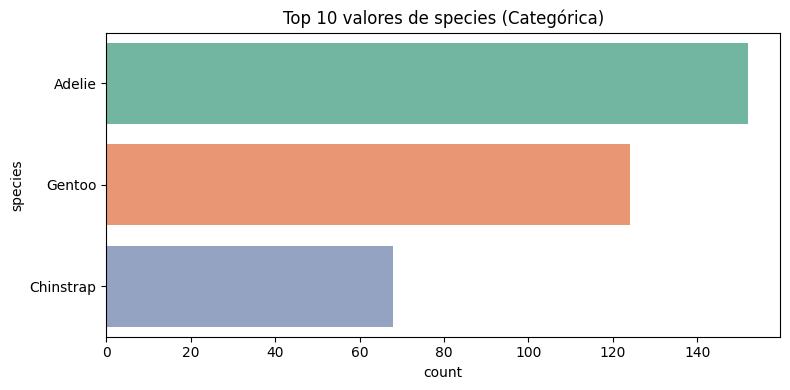

/tmp/ipykernel_450/4214399138.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().iloc[:10].index, palette='Set2')


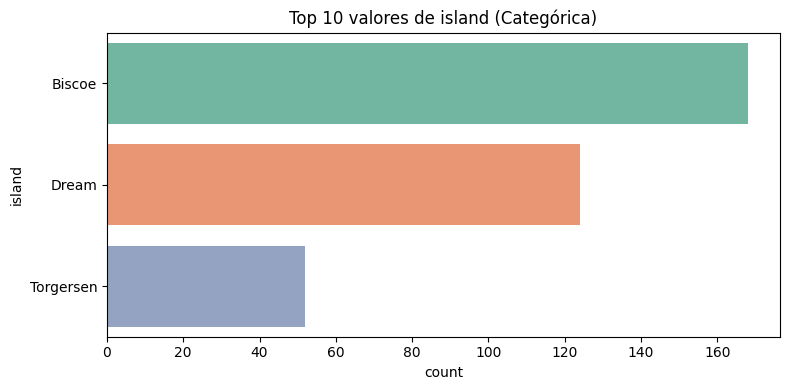

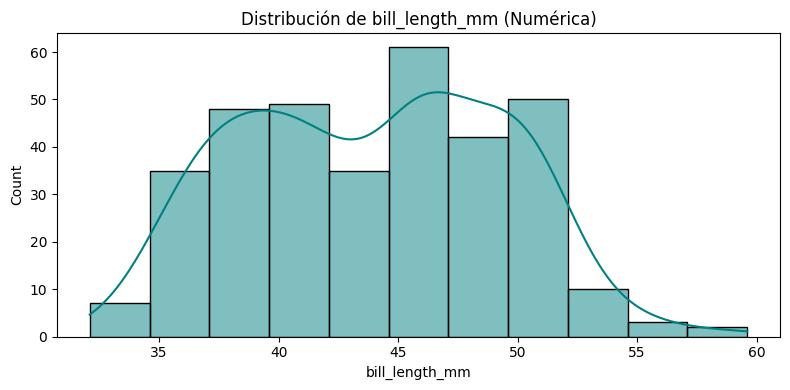

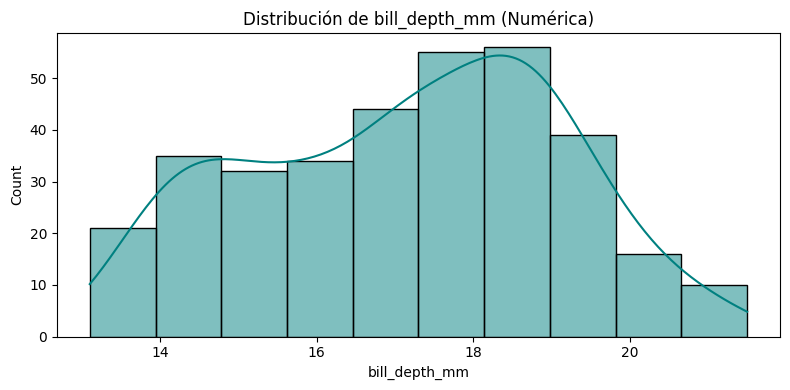

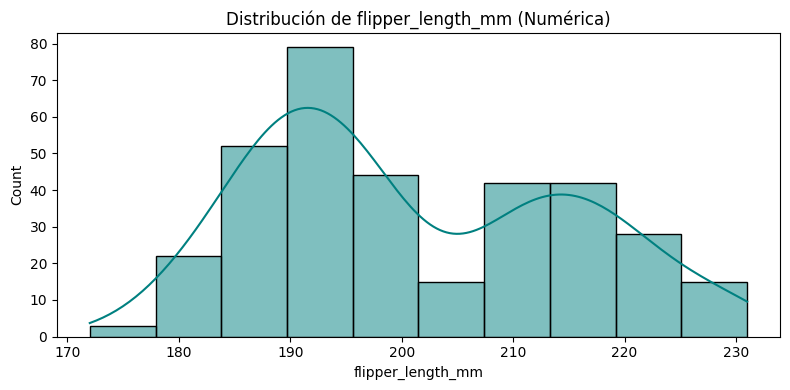

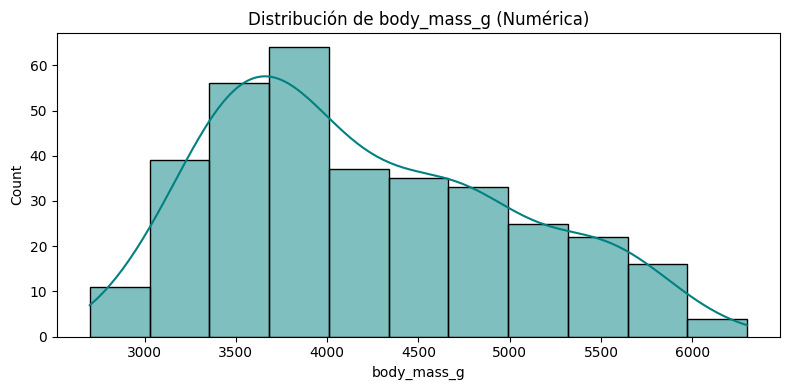

/tmp/ipykernel_450/4214399138.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().iloc[:10].index, palette='Set2')


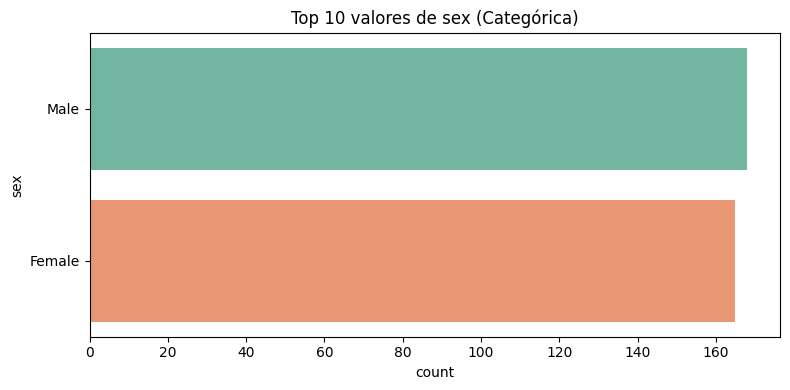

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

def explorar_dataset_automatico(df, carpeta_exportacion='exportacion_graficos'):
    if not os.path.exists(carpeta_exportacion):
        os.makedirs(carpeta_exportacion)
        print(f"Directorio '{carpeta_exportacion}' creado para guardar los gráficos.\n")

    for col in df.columns:
        plt.figure(figsize=(8, 4))

        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(df[col].dropna(), kde=True, color='teal')
            plt.title(f'Distribución de {col} (Numérica)')

        else:
            sns.countplot(y=df[col], order=df[col].value_counts().iloc[:10].index, palette='Set2')
            plt.title(f'Top 10 valores de {col} (Categórica)')

        plt.tight_layout()

        ruta_archivo = os.path.join(carpeta_exportacion, f"grafico_{col}.png")
        plt.savefig(ruta_archivo)

        plt.show()

        plt.close()

df_penguins = sns.load_dataset('penguins')
explorar_dataset_automatico(df_penguins)

## Ejercicio 2: Optimización de rutas (problema aplicado)

🌍 Contexto: La empresa no dispone de un control fiable del kilometraje de los desplazamientos de sus trabajadores. Antes de implementar un sistema avanzado, se quiere realizar una prueba piloto con trabajadores ubicados en España.
Para esta prueba:

» Se trabaja con una matriz de distancias entre ciudades.

» Se quiere una solución simple, razonable y explicable.

» No se busca la ruta óptima, sino una aproximación coherente.

Carga el archivo matriu_distancies.xlsxa pandas de modo que las filas y columnas sean las ciudades y se eliminen " Las Palmas de Gran Canaria " y " Palma ".

Desarrolla una función que:

» Reciba: una ciudad de origen y una ciudad de destino.

» Regreso: el orden de las ciudades visitadas (ruta) y la distancia total recorrida.

La ruta debe construirse siguiendo una estrategia sencilla: ir siempre a la ciudad no visitada más cercana hasta llegar al destino.

In [32]:
import pandas as pd
import numpy as np

df_dist = pd.read_excel('matriu_distancies.xlsx', index_col=0)

ciudades_a_quitar = ['Palma', 'Las Palmas de Gran Canaria']
df_dist = df_dist.drop(index=ciudades_a_quitar, columns=ciudades_a_quitar)

df_dist = df_dist.fillna(np.inf)

**» Recibir una ciudad de origen y una de destino.**
**» Devolver el orden de las ciudades visitadas y la distancia total.**
**» Estrategia: Ir siempre a la ciudad no visitada más cercana.**

---

Lo primero que he hecho tras cargar la matriz es eliminar las ciudades insulares ("Las Palmas de Gran Canaria" y "Palma"). Al tratarse de una prueba de kilometraje terrestre, mantener islas en la matriz generaría ruido analítico o distancias irreales. Además, he rellenado los valores nulos (la distancia de una ciudad a sí misma o rutas no conectadas) con `infinito` para evitar que el algoritmo las seleccione por error. He diseñado la función `calcular_ruta_voraz` utilizando exclusivamente operaciones de listas y condicionales. El algoritmo parte del origen, itera sobre la lista de ciudades disponibles verificando cuáles no están en la lista de `visitadas`, e identifica la que tiene el valor de distancia menor. Una vez encontrada, la añade a la ruta, suma los kilómetros, y la establece como el nuevo punto de partida. Este ciclo se repite hasta que la ciudad actual coincide con el destino.

In [33]:
def calcular_ruta_voraz(origen, destino, matriz):
    ruta = [origen]
    distancia_total = 0
    ciudad_actual = origen
    visitadas = {origen}

    while ciudad_actual != destino:
        distancias = matriz.loc[ciudad_actual]

        candidatas = distancias.drop(list(visitadas - {destino}))

        proxima_ciudad = candidatas.idxmin()
        distancia_paso = candidatas.min()

        ruta.append(proxima_ciudad)
        distancia_total += distancia_paso
        visitadas.add(proxima_ciudad)
        ciudad_actual = proxima_ciudad

    return ruta, distancia_total

ruta, distancia = calcular_ruta_voraz('Barcelona', 'Sevilla', df_dist)
print(f"Ruta: {' -> '.join(ruta)}")
print(f"Distancia total: {distancia} km")

Ruta: Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla
Distancia total: 1138.0 km
